In [1]:
# Python 3.13.1

In [21]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from collections import Counter
from torch.utils.data import WeightedRandomSampler
import numpy as np

# 경로 설정
TRAIN_DIR = r"/Users/ihaeni/dev/ai/computervision/data/train"
TEST_DIR = r"/Users/ihaeni/dev/ai/computervision/data/test"
BATCH_SIZE = 8 

# Train용 전처리 (Augmentation 포함)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Validation/Test용 전처리 (단순 Resize)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 전체 train dataset 불러오기
full_train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)

# 클래스 별 갯수 확인
print(Counter(full_train_dataset.targets))

# train:val = 8:2 split
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# test dataset
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=test_transform)

# Sampler 설정
train_indices = train_dataset.indices
train_targets = [full_train_dataset.targets[i] for i in train_indices]

from collections import Counter
class_counts = Counter(train_targets)
class_sample_count = np.array([class_counts[i] for i in range(len(class_counts))])
weights = 1. / class_sample_count
samples_weight = [weights[label] for label in train_targets]
sampler = WeightedRandomSampler(samples_weight, num_samples=len(samples_weight), replacement=True)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 클래스 이름 확인 (예: ['1', '2', '3', ...])
print("Classes:", full_train_dataset.classes)


Counter({1: 137, 3: 76, 5: 74, 0: 70, 2: 70, 4: 70, 6: 70, 7: 70, 8: 70, 9: 70})
Classes: ['1', '10', '2', '3', '4', '5', '6', '7', '8', '9']


In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


# CNN 모델 정의
class MyCNN(nn.Module):
    def __init__(self, num_classes):
        super(MyCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # ✅ Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d((1, 1))  # [B, 64, 1, 1]로 축소

        self.fc1 = nn.Linear(64, 128)  # 입력 크기: 64
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.leaky_relu(self.conv1(x)))
        x = self.pool(F.leaky_relu(self.conv2(x)))
        x = self.pool(F.leaky_relu(self.conv3(x)))

        x = self.gap(x)               # [B, 64, 1, 1]
        x = x.view(-1, 64)            # [B, 64]
        x = F.leaky_relu(self.fc1(x))
        x = self.fc2(x)
        return x

# 클래스 갯수 확인
num_classes = len(full_train_dataset.classes)
print(f"클래스 수: {num_classes}")

# 모델선언 및 학습준비
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MyCNN(num_classes=num_classes).to(device)

import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

클래스 수: 10


In [23]:
# 배치 하나 가져오기
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

# 모델 예측
model.eval()
with torch.no_grad():
    outputs = model(images)  # [B, num_classes]
    probs = torch.softmax(outputs, dim=1)  # 확률화

# 출력 확인
print("Logits (출력 원본):")
print(outputs[:2])  # 첫 두 개만 예시 출력

print("\nSoftmax 확률:")
print(probs[:2])

print("\n예측 클래스:", torch.argmax(probs, dim=1)[:2])
print("실제 정답:", labels[:2])

Logits (출력 원본):
tensor([[ 0.0385,  0.0334,  0.0522,  0.0069, -0.0671,  0.0772, -0.0917,  0.0455,
          0.1183, -0.0771],
        [ 0.0386,  0.0322,  0.0515,  0.0078, -0.0666,  0.0786, -0.0920,  0.0462,
          0.1173, -0.0768]])

Softmax 확률:
tensor([[0.1023, 0.1018, 0.1037, 0.0991, 0.0920, 0.1063, 0.0898, 0.1030, 0.1108,
         0.0911],
        [0.1023, 0.1016, 0.1036, 0.0992, 0.0921, 0.1065, 0.0898, 0.1031, 0.1107,
         0.0911]])

예측 클래스: tensor([8, 8])
실제 정답: tensor([7, 3])


In [24]:
# 학습 및 검증 손실, 정확도 저장용 리스트
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Best 모델 저장 & EarlyStopping 세팅
best_train_acc = 0.0                   # 지금까지 가장 높은 훈련 정확도
best_val_acc = 0.0                     # 지금까지 가장 높은 검증 정확도
best_model_state = None                # 그때의 모델 가중치 저장
patience = 3                           # 성능 향상이 없을 때 참을 수 있는 epoch 수
trigger_times = 0                      # 연속으로 향상되지 않은 횟수

# 학습 루프
for epoch in range(20):
    model.train()  # 모델을 학습 모드로 전환
    
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    # 미니배치 단위로 학습
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()             # 이전 그래디언트 초기화
        outputs = model(images)          # 순전파
        loss = criterion(outputs, labels)  # 손실 계산
        loss.backward()                  # 역전파
        optimizer.step()                 # 가중치 업데이트

        running_loss += loss.item()

        # 훈련 정확도 계산
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    scheduler.step()  # 학습률 감소 (StepLR 스케줄러)

    # 한 epoch 끝난 뒤 훈련 정확도 및 평균 손실 계산
    train_accuracy = 100 * correct_train / total_train
    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(train_accuracy)

    print(f"[Epoch {epoch+1}] Loss: {running_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%")

    # 검증 루프
    model.eval()
    correct = 0
    total = 0
    running_val_loss = 0.0

    with torch.no_grad():  # 검증 시에는 그래디언트 계산 비활성화
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # 검증 정확도 및 손실 저장
    val_accuracy = 100 * correct / total
    val_losses.append(running_val_loss / len(val_loader))
    val_accuracies.append(val_accuracy)

    #print(f"Validation Accuracy: {val_accuracy:.2f}%")

    # Best 모델 저장 & EarlyStopping 조건 체크
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_model_state = model.state_dict()
        best_train_acc = train_accuracy  

        trigger_times = 0  # 개선되었으므로 카운터 초기화
        #print(f"Best model updated at Epoch {epoch+1} (Val Acc: {val_accuracy:.2f}%)")
    else:
        trigger_times += 1
        #print(f"No improvement for {trigger_times} epoch(s)")

        if trigger_times >= patience:
            print("Early stopping triggered.")
            break  # 학습 조기 종료

[Epoch 1] Loss: 179.6976, Train Accuracy: 9.50%
[Epoch 2] Loss: 179.5445, Train Accuracy: 11.59%
[Epoch 3] Loss: 179.5191, Train Accuracy: 10.79%
[Epoch 4] Loss: 178.5398, Train Accuracy: 13.37%
[Epoch 5] Loss: 179.5628, Train Accuracy: 9.18%
Early stopping triggered.


Best model loaded with Validation Accuracy: 21.15%
Final Accuracy - Train: 11.59%, Val: 21.15%, Test: 10.00%


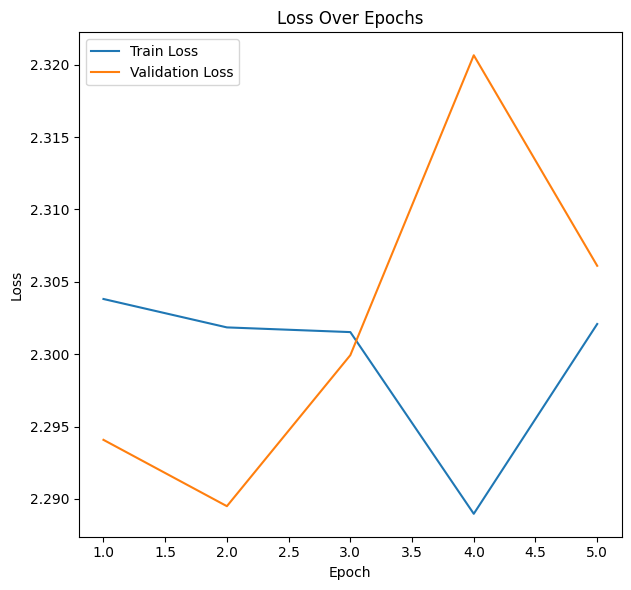

In [25]:
# 가장 성능 좋았던 모델로 복원
model.load_state_dict(best_model_state)
print(f"Best model loaded with Validation Accuracy: {best_val_acc:.2f}%")

# Test 데이터셋으로 최종 성능 평가
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Train / Val / Test Accuracy를 단순 Print
test_acc = 100 * correct / total
print(f"Final Accuracy - Train: {best_train_acc:.2f}%, Val: {best_val_acc:.2f}%, Test: {test_acc:.2f}%")


# 학습 과정 시각화
import matplotlib.pyplot as plt
epochs = range(1, len(train_accuracies) + 1)

plt.figure(figsize=(12, 6))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()